# IMPORT LIBRARIES

In [5]:
import pandas as pd
import numpy as np
import os
import pickle

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# LOAD DATASET

In [6]:

# df = pd.read_csv(r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered\rainfall_risk_engineered.csv")
df = pd.read_csv(r"D:\ClimateGuardAI\datasets\engineered\rainfall_risk_engineered.csv")

print(df.head())

   latitude  longitude  temperature_celsius  wind_kph  wind_degree  \
0     24.57      77.72                 27.5      20.5          281   
1     23.33      77.80                 27.5      15.5          287   
2     22.07      78.93                 26.3      18.4          317   
3     21.86      77.93                 25.6      16.9          297   
4     22.75      77.72                 27.2      16.2          274   

   pressure_mb  precip_mm  humidity  cloud  feels_like_celsius  ...  \
0         1008        0.0        67     26                29.7  ...   
1         1008        0.0        70     19                30.0  ...   
2         1009        0.0        70     51                28.2  ...   
3         1009        0.0        76     65                27.6  ...   
4         1009        0.0        74     82                29.9  ...   

   day_period_Night  season_Monsoon  season_Post_Monsoon  season_Summer  \
0               0.0             1.0                  0.0            0.0   
1 

# FEATURE ENGINEERING - TARGET CREATION

In [7]:
def create_heatwave_risk(temp):
    if temp < 35:
        return 'Safe'
    elif temp <= 42:
        return 'Warning'
    else:
        return 'Critical'

# df['heatwave_risk'] = df['feels_like_celsius'].apply(create_heatwave_risk)
df.loc[:, 'heatwave_risk'] = df['feels_like_celsius'].apply(create_heatwave_risk)
print(df['heatwave_risk'].value_counts())

heatwave_risk
Safe        118028
Warning       1333
Critical        37
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_16076\1050107789.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[:, 'heatwave_risk'] = df['feels_like_celsius'].apply(create_heatwave_risk)


# FEATURE SELECTION

In [8]:
features = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'precip_mm',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

X = df[features]
y = df['heatwave_risk']

X = X.fillna(X.mean(numeric_only=True))

# LABEL ENCODING (FIXED - CONSISTENT)

In [9]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# TRAIN-TEST SPLIT (USE ENCODED TARGET)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Model Training

## MODEL TRAINING - RANDOM FOREST

In [11]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print("\nBest RF Params:", rf_search.best_params_)



Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}


## MODEL TRAINING - XGBOOST

In [12]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_encoded)),
    eval_metric='mlogloss',
    random_state=42
)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

print("\nBest XGB Params:", xgb_search.best_params_)



Best XGB Params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.7}


# MODEL PREDICTIONS

In [13]:
rf_pred = rf_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)

# Convert back to original labels
rf_pred_labels = encoder.inverse_transform(rf_pred)
xgb_pred_labels = encoder.inverse_transform(xgb_pred)
y_test_labels = encoder.inverse_transform(y_test)

# MODEL COMPARISON (FIXED)

In [14]:
rf_accuracy = accuracy_score(y_test_labels, rf_pred_labels)
xgb_accuracy = accuracy_score(y_test_labels, xgb_pred_labels)

print("\nModel Comparison")
print("----------------")
print("Random Forest Accuracy :", rf_accuracy)
print("XGBoost Accuracy       :", xgb_accuracy)

if rf_accuracy > xgb_accuracy:
    best_model = rf_best
    best_name = "Random Forest"
else:
    best_model = xgb_best
    best_name = "XGBoost"

print("\nBest Model:", best_name)


Model Comparison
----------------
Random Forest Accuracy : 0.9970268006700167
XGBoost Accuracy       : 0.9961474036850921

Best Model: Random Forest


# CLASSIFICATION REPORT (FIXED)

In [15]:
best_pred = best_model.predict(X_test)
best_pred_labels = encoder.inverse_transform(best_pred)

print("\nClassification Report")
print(classification_report(y_test_labels, best_pred_labels))

cm = confusion_matrix(y_test_labels, best_pred_labels)
print("\nConfusion Matrix")
print(cm)


Classification Report
              precision    recall  f1-score   support

    Critical       1.00      0.29      0.44         7
        Safe       1.00      1.00      1.00     23606
     Warning       0.88      0.85      0.86       267

    accuracy                           1.00     23880
   macro avg       0.96      0.71      0.77     23880
weighted avg       1.00      1.00      1.00     23880


Confusion Matrix
[[    2     0     5]
 [    0 23581    25]
 [    0    41   226]]


# PREDICTION ON NEW DATA

In [16]:
new_data = pd.DataFrame({
    'temperature_celsius': [39],
    'humidity': [60],
    'pressure_mb': [1008],
    'wind_kph': [10],
    'precip_mm': [0],
    'visibility_km': [8],
    'air_quality_PM2.5': [55],
    'air_quality_PM10': [90]
})

prediction_encoded = best_model.predict(new_data)
prediction = encoder.inverse_transform(prediction_encoded)

print("\nPredicted Heatwave Risk:", prediction[0])


Predicted Heatwave Risk: Warning


# SAVE ENGINEERED DATASET

In [17]:
output_dir = r"D:\ClimateGuardAI\datasets\engineered"

# output_dir = r"C:\Users\hp\Documents\ClimateGuardAI\datasets\engineered"

output_path = f"{output_dir}/heatwave_risk_engineered.csv"
df.to_csv(output_path, index=False)

print("\nDataset saved at:", output_path)


Dataset saved at: D:\ClimateGuardAI\datasets\engineered/heatwave_risk_engineered.csv


# SAVE MODEL & ENCODER

In [18]:
save_path = r"D:\ClimateGuardAI\backend\ml\artifacts"
# save_path = r"C:\Users\hp\Documents\ClimateGuardAI\backend\ml\artifacts"

os.makedirs(save_path, exist_ok=True)

# Save model
with open(os.path.join(save_path, 'heatwave_risk_model.pkl'), 'wb') as file:
    pickle.dump(best_model, file) 

# Save encoder (IMPORTANT for deployment)
with open(os.path.join(save_path, 'heatwave_label_encoder.pkl'), 'wb') as file:
    pickle.dump(encoder, file)

print("\nModels saved successfully at:", save_path)


Models saved successfully at: D:\ClimateGuardAI\backend\ml\artifacts


# Distribution of Heatwave Risk Categories

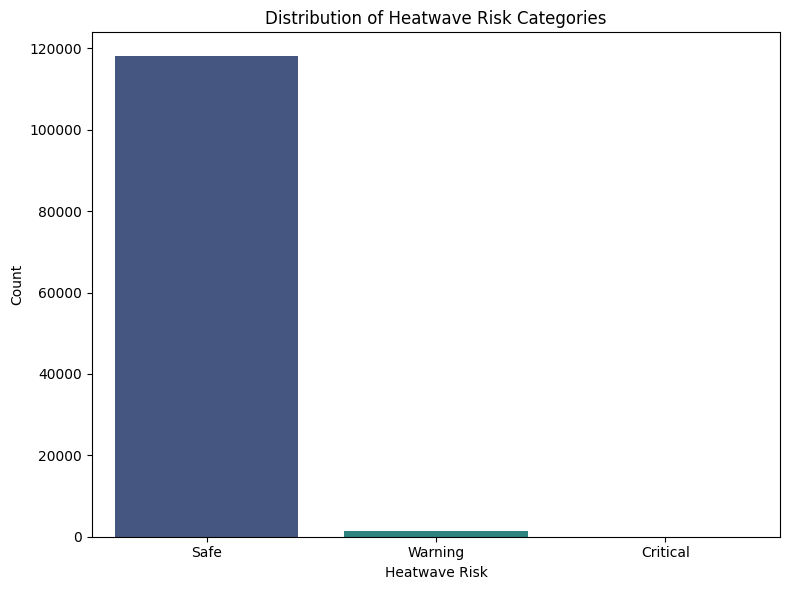

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize class imbalance
plt.figure(figsize=(8, 6))

order = df['heatwave_risk'].value_counts().index

# sns.countplot(
#     x='heatwave_risk',
#     data=df,
#     order=order,
#     palette='viridis'
# )
sns.countplot(
    x='heatwave_risk',
    data=df,
    order=order,
    hue='heatwave_risk',
    palette='viridis',
    legend=False
)
plt.title('Distribution of Heatwave Risk Categories')
plt.xlabel('Heatwave Risk')
plt.ylabel('Count')

plt.tight_layout()
plt.show() 